<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 02: El Concepto de Límite</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> XXX | <b>Fecha:</b> XX de XXX, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Esta sesión explora el concepto de <b>límite</b> como la base fundamental que sustenta las ramas del cálculo diferencial e integral. Investigaremos cómo los valores de una función se comportan cerca de un punto, independientemente de si la función está definida en dicho valor.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Definición intuitiva de límite y aproximación numérica.</li>
            <li>Límites laterales y detección de límites que no existen.</li>
            <li>Propiedades de los limites. </li>
            <li>Definición matemática - Ilustración gráfica.</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Estimar el valor de un límite tabulando datos usando <code>Pandas</code> y <code>NumPy</code>.</li>
            <li>Evaluar límites laterales y clasificar gráficamente discontinuidades o asíntotas.</li>
            <li>Automatizar el cálculo algebraico de límites utilizando <code>SymPy</code>.</li>
            <li>Visualizar gráficamente el confinamiento de la definición $\epsilon-\delta$.</li>
        </ul>
    </div>
</div>

In [3]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt, pandas as pd
from ipywidgets import interact

# Configuración para renderizado de ecuaciones y gráficas
sp.init_printing(use_latex='mathjax')
%matplotlib inline

# Configuración de estilo robusta para las rejillas de las gráficas
try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

# **1. Definición intuitiva de límite y aproximación numérica**

El concepto de **límite** es la base que sustenta las distintas ramas del Cálculo. En términos generales, el límite investiga qué ocurre con los valores de una función $f(x)$ a medida que la entrada $x$ se acerca a un número $a$, sin llegar necesariamente a ser igual a $a$.

### **Notación de Límite**
Supongamos que $f(x)$ está definida cuando $x$ está cerca del número $a$. Escribimos:

$$\lim_{x \to a} f(x) = L$$

Esta expresión se lee como: **"el límite de $f(x)$, cuando $x$ tiende a $a$, es igual a $L$"**.

Decimos que el límite es $L$ si podemos hacer que los valores de $f(x)$ estén arbitrariamente cercanos a $L$ tomando valores de $x$ suficientemente cerca de $a$ (por ambos lados), **pero no iguales a $a$**. Es fundamental notar que el valor de $f(a)$ no es relevante; el límite existe incluso si la función no está definida en dicho punto.

--------------------------------------------------------------------------------

### Ejemplo 1.1: Aproximación numérica básica

Para entender el concepto de **límite**, primero debemos observar cómo se comporta una función cerca de un valor específico, incluso si la función no está definida en ese punto. 

Consideremos la función:
$$f(x) = \frac{x^2 - 1}{x - 1}$$

**Tabla de valores**

Notemos que evaluar directamente en $x=1$ produce una indeterminación $\frac{0}{0}$. Sin embargo, podemos usar una **tabla de valores** para ver hacia dónde "tiende" la función a medida que $x$ se acerca a 1 por la izquierda (valores menores) y por la derecha (valores mayores).



In [1]:
# Definición de la función racional
def f(x): return (x**2 - 1) / (x - 1)

In [40]:
# Valores acercándose a 1 por ambos lados
puntos_izq = [0.5, 0.9, 0.95, 0.99, 0.95 , 0.999]
puntos_der = [1.5, 1.1, 1.05, 1.01, 1.005, 1.001]

# Crear tabla comparativa
df = pd.DataFrame({
    'x (Izq)': puntos_izq, 'f(x) Izq': f(np.array(puntos_izq)),
    'x (Der)': puntos_der, 'f(x) Der': f(np.array(puntos_der))
})

print("Comportamiento de f(x) cerca de x = 1:")
df.round(4)

Comportamiento de f(x) cerca de x = 1:


,x (Izq),f(x) Izq,x (Der),f(x) Der
0,0.500,1.500,1.500,2.500
1,0.900,1.900,1.100,2.100
2,0.950,1.950,1.050,2.050
3,0.990,1.990,1.010,2.010
4,0.950,1.950,1.005,2.005
5,0.999,1.999,1.001,2.001


**Representación Visual (Zoom in)**

Aunque las tablas numéricas sugieren la existencia de un límite, la gráfica de la función nos permite confirmar este comportamiento de forma intuitiva. 

Al graficar $$f(x) = \frac{x^2 - 1}{x - 1}$$ observaremos que en $x = 1$ no podemos evaluar, la curva parece dirigirse sin interrupciones hacia un valor específico de altura ($y$). En Cálculo, decimos que el límite es $L$ si los valores de salida se aproximan a $L$ a medida que $x$ se acerca a $a$ por cualquier lado.

Usa el control deslizante a continuación para realizar un **acercamiento (zoom in)** al punto crítico y observa hacia qué valor de $y$ converge la función.


In [4]:
@interact(zoom=(1, 50, 1))
def graficar_limite(zoom=1):
    # Definir un rango que se reduce según el zoom
    ancho = 2 / zoom
    x = np.linspace(1 - ancho, 1 + ancho, 500)
    x = x[x != 1] # Filtramos el 1 para evitar el error de división por cero
    
    plt.plot(x, f(x), color='blue', lw=2, label='$f(x)$')
    
    # Dibujar el punto (1, 2) donde no se evalua f
    plt.plot(1, 2, 'ro', fillstyle='none', markersize=10, label='$f(1)$ no definido')
    
    plt.title(f"Acercamiento al punto crítico (Zoom: {zoom}x)")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.axhline(2, color='gray', ls='--', alpha=0.5) # Línea guía en L=2
    plt.legend(); plt.show()


interactive(children=(IntSlider(value=1, description='zoom', max=50, min=1), Output()), _dom_classes=('widget-…

### Ejemplo 1.2: El límite fundamental trigonométrico
Evaluemos numéricamente $$\lim_{x \to 0} \frac{\sin(x)}{x}$$. Este límite es crucial en procesamiento de señales e ingeniería eléctrica.

In [18]:
# Ejemplo 1.2: Límite sen(x)/x
def f(x): return np.sin(x)/x
# Valores acercándose a 1 por ambos lados
puntos_izq = [-10,-5,-1,-0.5,-0.1, -0.05, -0.01, -0.005, -0.001 ]
puntos_der = [10,5,1,0.5,0.1, 0.05, 0.01, 0.005, 0.001,]

# Crear tabla comparativa
df = pd.DataFrame({
    'x (Izq)': puntos_izq, 'f(x) Izq': f(np.array(puntos_izq)),
    'x (Der)': puntos_der, 'f(x) Der': f(np.array(puntos_der))
})


print("Comportamiento de sin(x)/x cerca de x = 0:")
display(df.round(4))
print("El valor converge claramente hacia 1.0")


Comportamiento de sin(x)/x cerca de x = 0:


,x (Izq),f(x) Izq,x (Der),f(x) Der
0,-10.000,-0.0544,10.000,-0.0544
1,-5.000,-0.1918,5.000,-0.1918
2,-1.000,0.8415,1.000,0.8415
3,-0.500,0.9589,0.500,0.9589
4,-0.100,0.9983,0.100,0.9983
5,-0.050,0.9996,0.050,0.9996
6,-0.010,1.0000,0.010,1.0000
7,-0.005,1.0000,0.005,1.0000
8,-0.001,1.0000,0.001,1.0000


El valor converge claramente hacia 1.0


In [20]:
@interact(zoom=(1, 100, 1))
def graficar_limite2(zoom=1):
    # Definir un rango que se reduce según el zoom
    ancho = 20 / zoom
    x = np.linspace(0 - ancho,0 + ancho, 500)
    x = x[x != 0] # Filtramos el 0 para evitar el error de división por cero
    
    plt.plot(x, f(x), color='blue', lw=2, label='$\sin(x)/x$')
    
    # Dibujar el punto (1, 2) donde no se evalua f
    plt.plot(0, 1, 'ro', fillstyle='none', markersize=10, label='$f(0)$ no definido')
    
    plt.title(f"Acercamiento al punto crítico (Zoom: {zoom}x)")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.axhline(2, color='gray', ls='--', alpha=0.5) # Línea guía en L=2
    plt.legend(); plt.show()


interactive(children=(IntSlider(value=1, description='zoom', min=1), Output()), _dom_classes=('widget-interact…

### Ejemplo 1.3: Aproximación a la constante de Euler ($e$)
En el análisis de interés compuesto continuo o crecimiento de poblaciones, nos encontramos con el límite 
$$\lim_{x \to 0} (1+x)^{1/x}$$ Veamos a qué valor se aproxima.

In [25]:
# Ejemplo 1.3: Constante de Euler
def f_e(x): return (1 + x)**(1/x)
x_e = np.array([0.1,0.05,  0.01,0.005, 0.001,0.0005, 0.0001, 0.00005, 0.00001])


df_e = pd.DataFrame({'x': x_e, '(1+x)^(1/x)': f_e(x_e)})
display(df_e)
print(f"El valor se aproxima a la constante de Euler 'e' (aprox. {np.e:.5f})")


,x,(1+x)^(1/x)
0,0.10000,2.593742
1,0.05000,2.653298
2,0.01000,2.704814
3,0.00500,2.711517
4,0.00100,2.716924
5,0.00050,2.717603
6,0.00010,2.718146
7,0.00005,2.718214
8,0.00001,2.718268


El valor se aproxima a la constante de Euler 'e' (aprox. 2.71828)


In [27]:
@interact(zoom=(1, 100, 1))
def graficar_limite2(zoom=1):
    # Definir un rango que se reduce según el zoom
    ancho = 20 / zoom
    x = np.linspace(0 - ancho,0 + ancho, 500)
    x = x[x != 0] # Filtramos el 0 para evitar el error de división por cero
    
    plt.plot(x, f_e(x), color='blue', lw=2, label='$(1+x)^{1/x}$')
    
    # Dibujar el punto (1, 2) donde no se evalua f
    plt.plot(0, np.exp(1), 'ro', fillstyle='none', markersize=10, label='$f(0)$ no definido')
    
    plt.title(f"Acercamiento al punto crítico (Zoom: {zoom}x)")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.axhline(2, color='gray', ls='--', alpha=0.5) # Línea guía en L=2
    plt.legend(); plt.show()


interactive(children=(IntSlider(value=1, description='zoom', min=1), Output()), _dom_classes=('widget-interact…

# **2. Límites laterales y detección de límites que no existen**

El límite general solo existe si los límites laterales coinciden:
$$\lim_{x \to a^-} f(x) = \lim_{x \to a^+} f(x) = L$$
Existen tres razones principales por las que un límite puede fallar:
1. **Salto:** Los límites laterales existen pero son diferentes.
2. **Infinito:** La función crece sin cota (asíntota vertical).
3. **Oscilación:** La función oscila infinitamente y no se asienta en un valor.

### Ejemplo 2.1: Discontinuidad de Salto
Analicemos $f(x) = \frac{|x|}{x}$ cuando $x \to 0$.



In [28]:
# Ejemplo 2.1: Límite con Salto
x = sp.Symbol('x')
f_salto = sp.Abs(x) / x

lim_izq = sp.limit(f_salto, x, 0, dir='-')
lim_der = sp.limit(f_salto, x, 0, dir='+')

print(f"Límite por la izquierda: {lim_izq}")
print(f"Límite por la derecha: {lim_der}")
print("Dado que los límites laterales son distintos, el límite general NO EXISTE.")


Límite por la izquierda: -1
Límite por la derecha: 1
Dado que los límites laterales son distintos, el límite general NO EXISTE.


Observemos que otra forma de escribir esta funcion es:
$$
f(x) = \begin{cases}
-1 & \text{si } x<0,\\
1 & \text{si } x >0
\end{cases}
$$


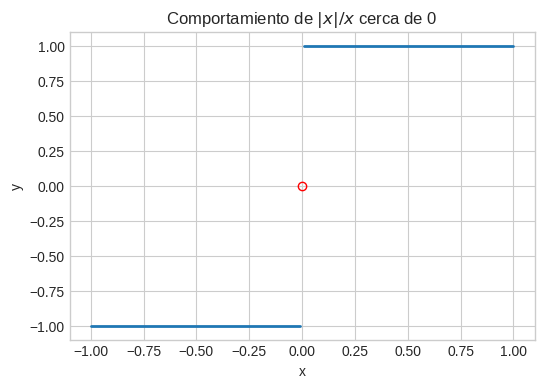

In [40]:
# Ejemplo 2.1: f(x) = |x|/x
x = np.linspace(-1, 1, 100)
# Evitar división por cero
x = x[x != 0] 
y = np.abs(x)/x

plt.plot(x[x<0], y[x<0], lw=2, color='C00')
plt.plot(x[x>0], y[x>0], lw=2, color='C00')
plt.plot(0,0,'o',fillstyle='none',color='r')
plt.title('Comportamiento de $|x|/x$ cerca de 0')
plt.xlabel('x');plt.ylabel('y'); plt.show()

## Límites Infinitos y limite al infinito*

Decimos que un límite es **infinito** cuando los valores de $f(x)$ crecen sin cota a medida que $x$ se acerca a $a$. Simbólicamente:
$$\lim_{x \to a} f(x) = \infty$$

Es importante recordar que $\infty$ no es un número; esta notación simplemente describe un comportamiento específico: la función aumenta arbitrariamente cerca del punto. 

**Definición de Asíntota Vertical:**
La recta $x = a$ se llama asíntota vertical de la curva $y = f(x)$ si el límite (o alguno de los límites laterales) en ese punto es infinito ($\infty$ o $-\infty$).

### Ejemplo 2.2: Límite Infinito (Asíntota Vertical)
Veamos qué ocurre con la función que describe la intensidad de la gravedad o campos eléctricos $\lim_{x \to 0} \frac{1}{x^2}$.


In [45]:
# Ejemplo 2.2: Límite Infinito
x = sp.Symbol('x')
f_inf = 1 / (x**2)
limite_inf = sp.limit(f_inf, x, 0)

print(f"El límite de 1/x^2 cuando x tiende a 0 es: {limite_inf}")
print("Al tender a infinito, decimos rigurosamente que el límite (como un número real) NO EXISTE.")


El límite de 1/x^2 cuando x tiende a 0 es: oo
Al tender a infinito, decimos rigurosamente que el límite (como un número real) NO EXISTE.


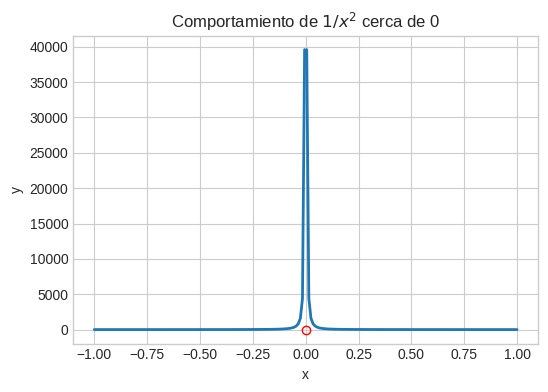

In [47]:
# Ejemplo 2.1: f(x) = 1 / (x**2)
x = np.linspace(-1, 1, 200)
def f22(x): return 1 / (x**2)
# Evitar división por cero
x = x[x != 0] 
y = f22(x)

plt.plot(x[x<0], y[x<0], lw=2, color='C00')
plt.plot(x[x>0], y[x>0], lw=2, color='C00')
plt.plot(0,0,'o',fillstyle='none',color='r')
plt.title('Comportamiento de $1/x^2$ cerca de 0')
plt.xlabel('x');plt.ylabel('y'); plt.show()

## Límites al Infinito y Asíntotas Horizontales

En esta sección investigamos qué ocurre con $f(x)$ cuando la variable independiente crese sin límite ($x \to \infty$) o decrece sin límite ($x \to -\infty$).

Si los valores de $f(x)$ se aproximan a un número real $L$ cuando $x$ es suficientemente grande, decimos que:
$$\lim_{x \to \infty} f(x) = L$$

En este caso, la recta **$y = L$** se denomina **asíntota horizontal** de la curva. Este concepto es clave para entender el comportamiento de "largo plazo" de los modelos matemáticos.

### Ejemplo 2.3: Límite Infinito (Asíntota Horizontal)
Veamos qué ocurre con la función racional 
$$\lim_{x \to 0} \frac{3 x^2 - x - 2}{5 x^2 + 4x + 1}. $$

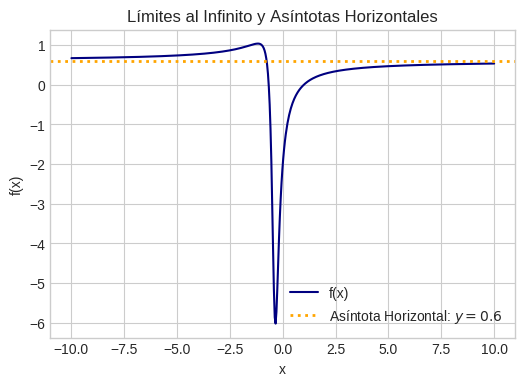

In [50]:
def f_racional(x): 
    return (3*x**2 - x - 2) / (5*x**2 + 4*x + 1)

x = np.linspace(-10, 10, 500)
plt.plot(x, f_racional(x), color='navy', label='f(x)')

# Dibujar Asíntota Horizontal en y = 3/5
plt.axhline(3/5, color='orange', ls=':', lw=2, label='Asíntota Horizontal: $y=0.6$')

plt.title("Límites al Infinito y Asíntotas Horizontales")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(); plt.show()

### Ejemplo 2.4: Comportamiento Oscilatorio
Veamos gráficamente por qué $$\lim_{x \to 0} \sin\left(\frac{1}{x}\right)$$ no existe.


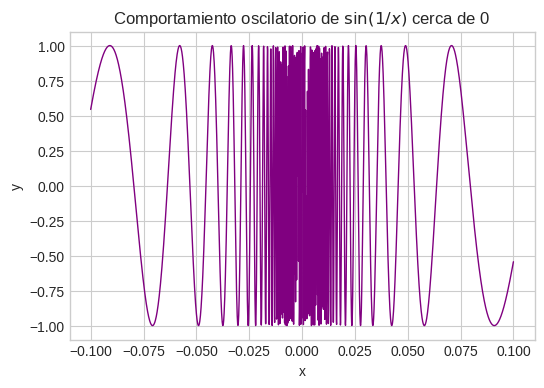

La función oscila infinitamente entre -1 y 1. Nunca se acerca a un único valor L.


In [51]:
# Ejemplo 2.3: Oscilación infinita
x_osc = np.linspace(-0.1, 0.1, 2000)
# Evitar división por cero
x_osc = x_osc[x_osc != 0] 
y_osc = np.sin(1 / x_osc)

plt.plot(x_osc, y_osc, lw=1, color='purple')
plt.title('Comportamiento oscilatorio de $\sin(1/x)$ cerca de 0')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
print("La función oscila infinitamente entre -1 y 1. Nunca se acerca a un único valor L.")


# **3. Propiedades de los Límites**

Para calcular límites analíticamente sin depender de tablas o gráficas, usamos las **leyes de los límites** (suma, producto, cociente, potencia, raíz). Computacionalmente, `SymPy` aplica todas estas reglas de forma robusta empleando herramientas avanzadas de álgebra simbólica.


### Ejemplo 3.1: Sustitución Directa
Si $f(x)$ es un polinomio o una función racional (y el denominador no es cero en $a$), entonces 
$$\lim_{x \to a} f(x) = f(a)$$.


In [61]:
# Ejemplo 3.1: Polinomios
x = sp.Symbol('x')
f_poli = 3*x**2 + 5*x - 1
limite_poli = sp.limit(f_poli, x, 2)

print("Límite de (3x^2 + 5x - 1) cuando x -> 2:")
display(limite_poli)
print(f"Comprobación por sustitución: 3(2)^2 + 5(2) - 1 = {3*(2**2) + 5*2 - 1}")


Límite de (3x^2 + 5x - 1) cuando x -> 2:


21

Comprobación por sustitución: 3(2)^2 + 5(2) - 1 = 21


### Ejemplo 3.2: Indeterminación y Factorización
Calculemos el límite $$\lim_{x \to -3} \frac{x^2 + 5x + 6}{x^2 - 9}$$


In [62]:
# Ejemplo 3.2: Factorización
f_rac = (x**2 + 5*x + 6) / (x**2 - 9)

# 1. Veamos qué pasa si simplificamos la expresión algebraicamente
f_simplificada = sp.simplify(f_rac)
print("Expresión factorizada y simplificada:")
display(f_simplificada)

# 2. Calculamos el límite de la función original
lim_rac = sp.limit(f_rac, x, -3)
print("\nResultado del límite cuando x -> -3:")
display(lim_rac)


Expresión factorizada y simplificada:


x + 2
─────
x - 3


Resultado del límite cuando x -> -3:


1/6

### Ejemplo 3.3: Racionalización
Calculemos el límite de una expresión con raíces: $$\lim_{x \to 0} \frac{\sqrt{x^2+9} - 3}{x^2}$$


In [65]:
# Ejemplo 3.3: Racionalización
f_raiz = (sp.sqrt(x**2 + 9) - 3) / x**2
lim_raiz = sp.limit(f_raiz, x, 0)

print("Límite de")
display(f_raiz)
print(" cuando x -> 0:")
display(lim_raiz)


Límite de


   ________    
  ╱  2         
╲╱  x  + 9  - 3
───────────────
       2       
      x        

 cuando x -> 0:


1/6

# **4. Definición Matemática Formal ($\epsilon - \delta$)**

La definición rigurosa dice que 
$$\lim_{x \to a} f(x) = L$$ 
si para todo número $\epsilon > 0$ existe un número $\delta > 0$ tal que:
$$ \text{si } 0 < |x - a| < \delta \implies |f(x) - L| < \epsilon $$

Geométricamente, esto significa que si restringimos los valores de salida (el eje $y$) a un "tubo" de anchura $2\epsilon$ alrededor de $L$, siempre podemos encontrar una ventana en el eje $x$ de anchura $2\delta$ alrededor de $a$ que garantice que la gráfica de la función se mantenga dentro del tubo.

### Ejemplo 4.1 
Ilustracion del limite
$$
\lim_{x \to 3} 2x-1 = 5
$$

In [71]:
# Ejemplo 4.1
def animar_limite(epsilon=1.0):
    a = 3; L = 5
    delta = epsilon / 2  
    f_lineal = lambda x: 2*x - 1
    
    fig, ax = plt.subplots()
    x_vals = np.linspace(a - 2, a + 2, 400)
    y_vals = f_lineal(x_vals)
    ax.plot(x_vals, y_vals, color='blue', label='$f(x)$')
    
    # Dibujamos las bandas (redondeamos a 2 decimales para que el texto se vea limpio)
    ax.axhspan(L - epsilon, L + epsilon, color='red', alpha=0.15, label=f'Banda $\epsilon$ ({L} $\pm$ {epsilon:.2f})')
    ax.axvspan(a - delta, a + delta, color='green', alpha=0.15, label=f'Banda $\delta$ ({a} $\pm$ {delta:.2f})')
    
    # Dibujamos el punto central
    ax.plot(a, L, 'ko', label=f'({a}, {L})')
    

    ax.set_title(f"Límite Lineal: f(x) = 2x - 1 \n $\epsilon$ = {epsilon:.2f}, $\delta$ = {delta:.2f}")
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(a - 1, a + 1)
    ax.set_ylim(L - 2, L + 2)
    plt.show()

interact(animar_limite, epsilon=(0.01, 0.5, 0.01));

interactive(children=(FloatSlider(value=0.5, description='epsilon', max=0.5, min=0.01, step=0.01), Output()), …

### Ejemplo 4.2: (Asimetría)
Para 
$$\lim_{x \to 2} x^2 = 4$$
con $\epsilon = 1$, la banda $\delta$ ya no es perfectamente simétrica algebraicamente, pero tomamos el $\delta$ más pequeño para asegurar que la función se mantenga dentro de la banda $\epsilon$.


In [86]:
# Ejemplo 4.1
def animar_limite(epsilon=1.0):
    a = 2.0; L = 4.0

    delta_no_lineal = min(2.0-np.sqrt(4.0-epsilon), np.sqrt(epsilon+4.0)-2.0) 
    f_cuadrada = lambda x: x**2
    
    fig, ax = plt.subplots()
    x_vals = np.linspace(a - 2, a + 2, 400)
    y_vals = f_cuadrada(x_vals)
    ax.plot(x_vals, y_vals, color='blue', label='$f(x)$')
    
    # Dibujamos las bandas (redondeamos a 2 decimales para que el texto se vea limpio)
    ax.axhspan(L - epsilon, L + epsilon, color='red', alpha=0.15, label=f'Banda $\epsilon$ ({L} $\pm$ {epsilon:.2f})')
    ax.axvspan(a - delta_no_lineal, a + delta_no_lineal, color='green', alpha=0.15, label=f'Banda $\delta$ ({a} $\pm$ {delta_no_lineal:.2f})')
    
    # Dibujamos el punto central
    ax.plot(a, L, 'ko', label=f'({a}, {L})')
    

    ax.set_title(f"Límite Lineal: f(x) = x^2 \n $\epsilon$ = {epsilon:.2f}, $\delta$ = {delta_no_lineal:.2f}")
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim(a - 1, a + 1)
    ax.set_ylim(L - 2, L + 2)
    plt.show()

interact(animar_limite, epsilon=(0.01, 1, 0.01));


interactive(children=(FloatSlider(value=1.0, description='epsilon', max=1.0, min=0.01, step=0.01), Output()), …

<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Hemos llegado al final de los contenidos de este laboratorio. Ahora es tu turno de poner en práctica lo que aprendiste resolviendo los siguientes retos computacionales.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>


### Ejercicio 1: Aproximación Numérica
La velocidad límite de un objeto al caer con resistencia al aire viene dada por la ecuación $v(t) = \frac{mg}{c}(1 - e^{-ct/m})$. 
Cree una tabla de valores con NumPy y Pandas para estimar el límite de la velocidad a medida que el tiempo $t$ tiende a infinito (evalúe $t$ en 10, 50, 100, 500). Asuma $m=70$, $g=9.8$, $c=12$

---

In [ ]:
# Escriba su código aquí

### Ejercicio: Límites Laterales
Investigue el límite de la función escalón unitario modificado: $f(x) = \frac{1}{1 + 2^{1/x}}$ cuando $x \to 0$.
1. Calcule los límites por la izquierda y por la derecha usando SymPy.
2. ¿Existe el límite general?

---


In [ ]:
# Escriba su código aquí

### Ejercicio 3: 
Investigue el límite de la funcion $f(x) = \frac{\sin(x)}{ x}$ cuando $x\to 0$.

1. Grafique la funcion y crea una tabla que aproxime el valor del limite.
2. Calcule los límites por la izquierda y por la derecha usando SymPy.
3. ¿Existe el límite general?


In [ ]:
# Escriba su código aquí

### Ejercicio 4: 
Investigue el límite de la funcion $f(x) = \frac{\cos(x) - 1}{ x}$ cuando $x\to 0$.

1. Grafique la funcion y crea una tabla que aproxime el valor del limite.
2. Calcule los límites por la izquierda y por la derecha usando SymPy.
3. ¿Existe el límite general?


In [ ]:
# Escriba su código aquí


### Ejercicio 5
Investigue el límite de la funcion $f(t) = \frac{\sqrt{t^2 + 9} - 3)}{ t^2}$ cuando $t\to 0$.

1. Grafique la funcion y crea una tabla que aproxime el valor del limite.
2. Calcule los límites por la izquierda y por la derecha usando SymPy.
3. ¿Existe el límite general?


In [ ]:
# Escriba su código aquí

### Pregunta 6

In [89]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración de la pregunta
pregunta = widgets.RadioButtons(
    options=[
        ('El límite es 0', 1),
        ('El límite es 1', 2),
        ('El límite no existe por oscilación', 3),
        ('El límite es infinito', 4)
    ],
    description='¿Cuál es el límite de $\sin(\pi/x)$ cuando $x$ → $0$?',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)

boton = widgets.Button(description="Verificar", button_style='info')
salida = widgets.Output()

def verificar(b):
    with salida:
        clear_output()
        if pregunta.value == 3:
            print("✅ ¡Correcto! La función nunca se estabiliza en un valor único.")
        else:
            print("❌ Incorrecto. Observa la gráfica de nuevo: la función salta entre -1 y 1 sin parar.")

boton.on_click(verificar)
display(pregunta, boton, salida)

RadioButtons(description='¿Cuál es el límite de $\\sin(\\pi/x)$ cuando $x$ → $0$?', layout=Layout(width='max-c…

Button(button_style='info', description='Verificar', style=ButtonStyle())

Output()

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>